# 05. Regressão Logística

Este notebook implementa e avalia o modelo de **Regressão Logística** aplicado ao dataset **Breast Cancer Wisconsin Diagnostic (WDBC)**.

A análise é estruturada em quatro etapas progressivas:

1. **Modelo base** — parâmetros padrão, sem otimização
2. **Otimização de `class_weight`** — penalização assimétrica de erros
3. **Otimização de threshold** — ajuste do ponto de corte da decisão

O foco principal é analisar o **Recall**, métrica prioritária neste trabalho, dado que um falso negativo tem custo clínico substancialmente maior que um falso positivo.

---
## 1. Importações e Configuração do Ambiente

In [19]:
# 1. Importando bibliotecas e pipeline centralizado

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from pipeline import run_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    recall_score, precision_score, accuracy_score, f1_score,
)

---
## 2. Carregamento dos Dados

In [20]:
# 2. Carregando os dados pré-processados e padronizados
X_train, X_test, y_train, y_test = run_pipeline()

---
## 3. Modelo Base

O modelo base utiliza todos os parâmetros padrão do sklearn, sem implementar nenhuma otimização. Serve como ponto de referência para avaliar o impacto de cada ajuste nas etapas seguintes.

Parâmetros padrão relevantes:
- `class_weight = None` — classes tratadas igualmente
- `threshold = 0.5` — ponto de corte padrão

In [45]:
# 3.1 Treinando e avaliando o modelo base
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train, y_train)

y_pred_baseline = lr_baseline.predict(X_test)

print("=" * 50)
print("REGRESSÃO LOGÍSTICA — BASE")
print("=" * 50)
print(classification_report(y_test, y_pred_baseline,
      target_names=["Benigno", "Maligno"]))
print(f"Recall (Maligno)  : {recall_score(y_test, y_pred_baseline):.4f}")
print(f"Falsos Negativos  : {confusion_matrix(y_test, y_pred_baseline)[1][0]}")

REGRESSÃO LOGÍSTICA — BASE
              precision    recall  f1-score   support

     Benigno       0.96      0.99      0.97        72
     Maligno       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

Recall (Maligno)  : 0.9286
Falsos Negativos  : 3


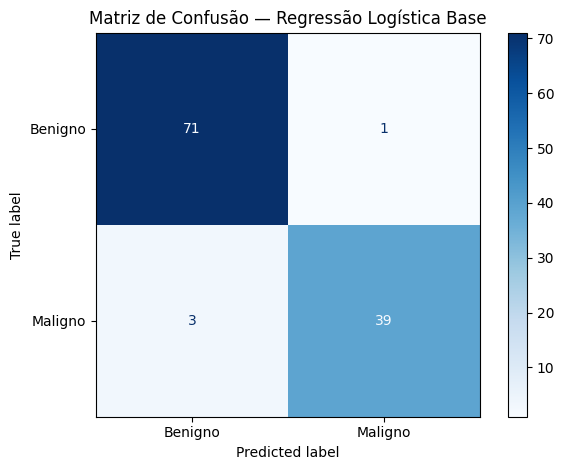

In [23]:
# 3.3 Matriz de confusão — Modelo Base
cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(cm, display_labels=["Benigno", "Maligno"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusão — Regressão Logística Base")
plt.tight_layout()
plt.savefig("outputs/matriz_lr_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 4. Modelo com Otimização dos Pesos das Classes

Por padrão, o modelo trata erros em Benigno e Maligno como igualmente custosos. O `class_weight` permite atribuir maior penalidade aos erros na classe Maligno durante o **treino**, forçando o modelo a aprender a priorizá-la.


In [ ]:
# 4.1 Testando class_weight='balanced' vs padrão
configs = [
    ("Padrão",    None),                #padrão -> sem pesos 
    ("Balanced",         'balanced'),
]

print(f"{'Configuração':<22} {'Recall':>8} {'Precisão':>10} {'Acurácia':>10} {'F1':>8} {'Falsos Neg.':>13}")
print("-" * 75)

#cw = balenced -> ele calcula os pesos de cada classe com base no numero de casos (benigno e maligno) de cada no teste
for nome, cw in configs:
    lr = LogisticRegression(class_weight=cw, max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    rec  = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    fn   = confusion_matrix(y_test, y_pred)[1][0]
    print(f"{nome:<22} {rec:>8.4f} {prec:>10.4f} {acc:>10.4f} {f1:>8.4f} {fn:>13}")

Configuração             Recall   Precisão   Acurácia       F1   Falsos Neg.
---------------------------------------------------------------------------
Padrão                   0.9286     0.9750     0.9649   0.9512             3
Balanced                 0.9524     0.9756     0.9737   0.9639             2


In [25]:
# 4.2 Testando pesos manuais para a classe Maligno
pesos = [1, 2, 3, 5, 10]
resultados_peso = []

print(f"{'Peso Maligno':<14} {'Recall':>8} {'Precisão':>10} {'Acurácia':>10} {'F1':>8} {'Falsos Neg.':>13}")
print("-" * 65)

for peso in pesos:
    lr = LogisticRegression(
        class_weight={0: 1, 1: peso},
        max_iter=1000, random_state=42
    )
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    rec  = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    fn   = confusion_matrix(y_test, y_pred)[1][0]
    print(f"{peso:<14} {rec:>8.4f} {prec:>10.4f} {acc:>10.4f} {f1:>8.4f} {fn:>13}")
    resultados_peso.append((peso, rec, prec, acc, f1, fn))

# Razões do peso das classes
# 1.346 / 0.795 ≈ 1.69 (caso cw = balanced)
# 1 / 2  ≈ 2.0
# 1 / 3  ≈ 3.0
# 1 / 5  ≈ 5.0

Peso Maligno     Recall   Precisão   Acurácia       F1   Falsos Neg.
-----------------------------------------------------------------
1                0.9286     0.9750     0.9649   0.9512             3
2                0.9524     0.9756     0.9737   0.9639             2
3                0.9524     0.9756     0.9737   0.9639             2
5                0.9524     0.9756     0.9737   0.9639             2
10               0.9524     0.9302     0.9561   0.9412             2


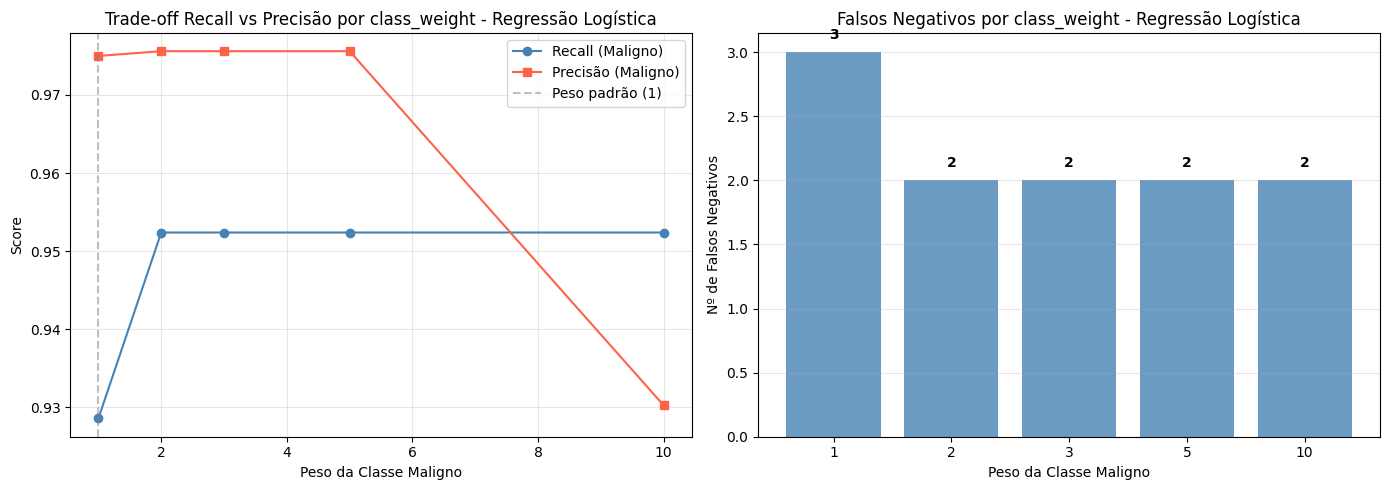

In [43]:
# 4.3 Gráfico — Recall e Precisão por peso da classe Maligno
ps   = [r[0] for r in resultados_peso]
recs = [r[1] for r in resultados_peso]
pres = [r[2] for r in resultados_peso]
fns  = [r[5] for r in resultados_peso]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ps, recs, marker='o', color='steelblue', label='Recall (Maligno)')
axes[0].plot(ps, pres, marker='s', color='tomato',    label='Precisão (Maligno)')
axes[0].axvline(x=1, color='gray', linestyle='--', alpha=0.5, label='Peso padrão (1)')
axes[0].set_xlabel('Peso da Classe Maligno')
axes[0].set_ylabel('Score')
axes[0].set_title('Trade-off Recall vs Precisão por class_weight - Regressão Logística')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar([str(p) for p in ps], fns, color='steelblue', alpha=0.8)
axes[1].set_xlabel('Peso da Classe Maligno')
axes[1].set_ylabel('Nº de Falsos Negativos')
axes[1].set_title('Falsos Negativos por class_weight - Regressão Logística')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(fns):
    axes[1].text(i, v + 0.1, str(int(v)), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("outputs/classweight_lr.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 5. Modelo com Otimização do Threshold

O threshold define o ponto de corte da probabilidade para classificar um tumor como Maligno. O padrão é 0.5, ou seja, o modelo só classifica como Maligno quando a probabilidade calculada supera 50%.


In [27]:
# 5.1 Distribuição das probabilidades — Regressão Logística baseline
y_proba_lr = lr_baseline.predict_proba(X_test)[:, 1]

print("Distribuição das probabilidades (classe Maligno):")
print(pd.Series(y_proba_lr).describe().round(4))
print()
print("Casos com probabilidade entre 0.2 e 0.5:")
mascara = (y_proba_lr >= 0.2) & (y_proba_lr < 0.5)
print(f"Total: {mascara.sum()} casos")
print(pd.Series(y_proba_lr[mascara]).round(3).values)

Distribuição das probabilidades (classe Maligno):
count    114.0000
mean       0.3532
std        0.4486
min        0.0000
25%        0.0005
50%        0.0152
75%        0.9727
max        1.0000
dtype: float64

Casos com probabilidade entre 0.2 e 0.5:
Total: 5 casos
[0.222 0.235 0.315 0.201 0.492]


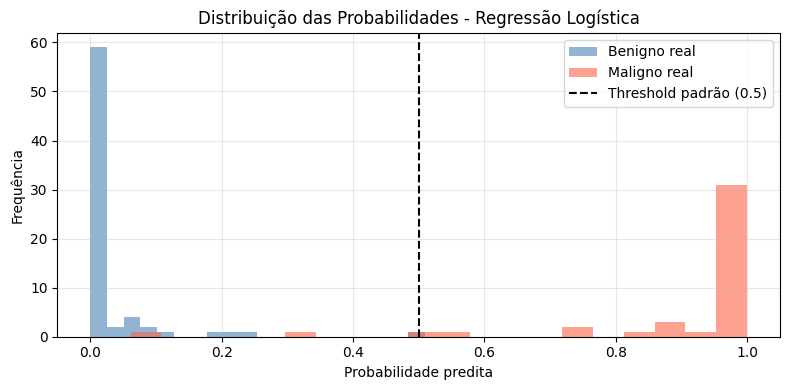

In [31]:
# 5.2 Histograma das probabilidades preditas
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_proba_lr[y_test == 0], bins=20, alpha=0.6, color='steelblue', label='Benigno real')
ax.hist(y_proba_lr[y_test == 1], bins=20, alpha=0.6, color='tomato',    label='Maligno real')
ax.axvline(x=0.5, color='black', linestyle='--', label='Threshold padrão (0.5)')
ax.set_xlabel('Probabilidade predita')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição das Probabilidades - Regressão Logística')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/distribuicao_proba_lr.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
# 5.3 Tabela de métricas por threshold
print("=== ANÁLISE DE THRESHOLD — Regressão Logística ===")
print(f"{'Threshold':<12} {'Recall':>8} {'Precisão':>10} {'Acurácia':>10} {'F1':>8} {'Falsos Neg.':>13}")
print("-" * 65)

thresholds = [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2]
resultados_threshold = []

for t in thresholds:
    y_pred_t = (y_proba_lr >= t).astype(int)
    rec  = recall_score(y_test, y_pred_t)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    acc  = accuracy_score(y_test, y_pred_t)
    f1   = f1_score(y_test, y_pred_t)
    fn   = confusion_matrix(y_test, y_pred_t)[1][0]
    print(f"{t:<12.2f} {rec:>8.4f} {prec:>10.4f} {acc:>10.4f} {f1:>8.4f} {fn:>13}")
    resultados_threshold.append((t, rec, prec, acc, f1, fn))

=== ANÁLISE DE THRESHOLD — Regressão Logística ===
Threshold      Recall   Precisão   Acurácia       F1   Falsos Neg.
-----------------------------------------------------------------
0.50           0.9286     0.9750     0.9649   0.9512             3
0.45           0.9524     0.9756     0.9737   0.9639             2
0.40           0.9524     0.9756     0.9737   0.9639             2
0.35           0.9524     0.9756     0.9737   0.9639             2
0.30           0.9762     0.9762     0.9825   0.9762             1
0.25           0.9762     0.9762     0.9825   0.9762             1
0.20           0.9762     0.9111     0.9561   0.9425             1


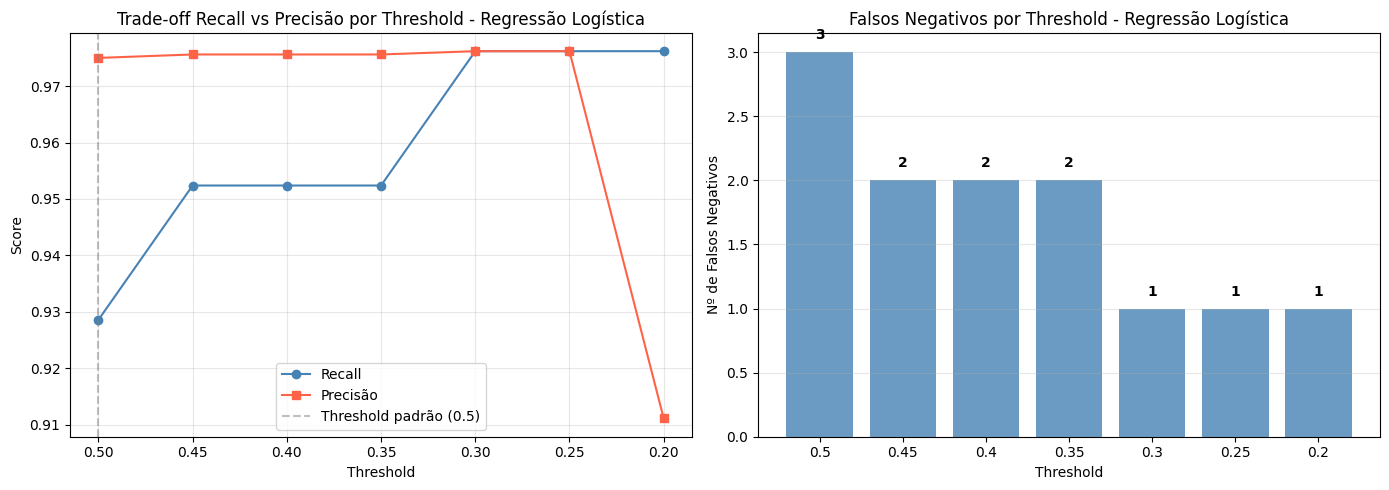

In [36]:
# 5.4 Gráficos do trade-off por threshold
ts   = [r[0] for r in resultados_threshold]
recs = [r[1] for r in resultados_threshold]
pres = [r[2] for r in resultados_threshold]
fns  = [r[5] for r in resultados_threshold]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ts, recs, marker='o', color='steelblue', label='Recall')
axes[0].plot(ts, pres, marker='s', color='tomato',    label='Precisão')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold padrão (0.5)')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Trade-off Recall vs Precisão por Threshold - Regressão Logística')
axes[0].legend()
axes[0].invert_xaxis()
axes[0].grid(alpha=0.3)

axes[1].bar([str(t) for t in ts], fns, color='steelblue', alpha=0.8)
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Nº de Falsos Negativos')
axes[1].set_title('Falsos Negativos por Threshold - Regressão Logística')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(fns):
    axes[1].text(i, v + 0.1, str(int(v)), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("outputs/threshold_lr.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 6. Combinação dos Melhores Hiperparâmetros

Com base nos resultados anteriores, esta seção combina `class_weight='balanced'` e o threshold otimizado para obter o modelo final com maior Recall.

A progressão abaixo mostra o efeito acumulado de cada ajuste:

In [46]:
# 6.1 Progressão de otimizações
configuracoes = [
    ("1. Base",                    1.0,  None,       0.50),
    ("2. Threshold ajustado",           1.0,  None,       0.30),
    ("3. Class weight balanced",        1.0,  {0: 1, 1: 2}, 0.50),
    ("4. Class weight + Threshold",     1.0,  {0: 1, 1: 2}, 0.30),
]

print(f"{'Configuração':<30} {'Recall':>8} {'Precisão':>10} {'Acurácia':>10} {'F1':>8} {'Falsos Neg.':>13}")
print("-" * 82)

resultados_prog = []
for nome, c, cw, t in configuracoes:
    lr = LogisticRegression(C=c, class_weight=cw, max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    proba = lr.predict_proba(X_test)[:, 1]
    y_pred = (proba >= t).astype(int)
    rec  = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    fn   = confusion_matrix(y_test, y_pred)[1][0]
    print(f"{nome:<30} {rec:>8.4f} {prec:>10.4f} {acc:>10.4f} {f1:>8.4f} {fn:>13}")
    resultados_prog.append((nome, rec, prec, acc, f1, fn))

Configuração                     Recall   Precisão   Acurácia       F1   Falsos Neg.
----------------------------------------------------------------------------------
1. Base                          0.9286     0.9750     0.9649   0.9512             3
2. Threshold ajustado            0.9762     0.9762     0.9825   0.9762             1
3. Class weight balanced         0.9524     0.9756     0.9737   0.9639             2
4. Class weight + Threshold      0.9524     0.9302     0.9561   0.9412             2


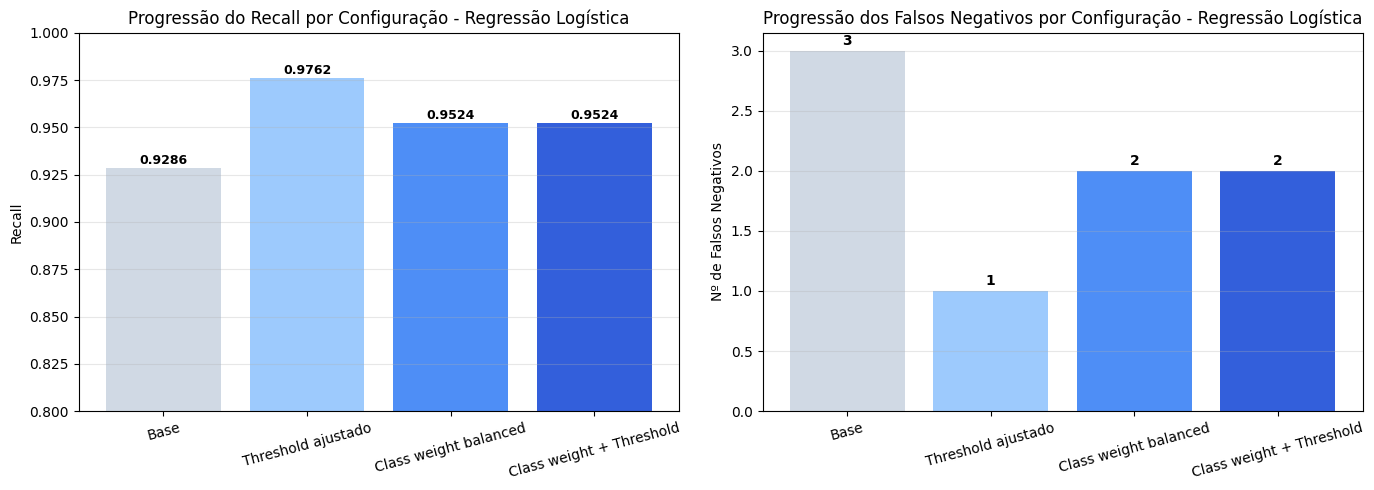

In [47]:
# 6.2 Gráfico da progressão de Recall por configuração
nomes = [r[0].split(".")[1].strip() for r in resultados_prog]
recs  = [r[1] for r in resultados_prog]
fns   = [r[5] for r in resultados_prog]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores = ['#CBD5E1', '#93C5FD', '#3B82F6', '#1D4ED8']
bars = axes[0].bar(nomes, recs, color=cores, alpha=0.9)
axes[0].set_ylabel('Recall')
axes[0].set_title('Progressão do Recall por Configuração - Regressão Logística')
axes[0].set_ylim(0.8, 1.0)
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, recs):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.002,
                 f"{v:.4f}", ha='center', fontsize=9, fontweight='bold')

bars2 = axes[1].bar(nomes, fns, color=cores, alpha=0.9)
axes[1].set_ylabel('Nº de Falsos Negativos')
axes[1].set_title('Progressão dos Falsos Negativos por Configuração - Regressão Logística')
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=15)
for bar, v in zip(bars2, fns):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.05,
                 str(int(v)), ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("outputs/progressao_lr.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 7. Avaliação Final do Modelo Otimizado

O modelo final utiliza a combinação de hiperparâmetros que obteve o melhor Recall na etapa anterior.

In [44]:
# 7.1 Treinando o modelo final otimizado
# Ajuste os valores de C e threshold conforme os resultados da seção 7
C_otimo        = 1.0        # ajuste conforme resultado da seção 4
threshold_otimo = 0.30      # ajuste conforme resultado da seção 6

lr_final = LogisticRegression(
    C=C_otimo,
    max_iter=1000,
    random_state=42
)
lr_final.fit(X_train, y_train)
y_proba_final = lr_final.predict_proba(X_test)[:, 1]
y_pred_final  = (y_proba_final >= threshold_otimo).astype(int)

print("=" * 55)
print("REGRESSÃO LOGÍSTICA — MODELO FINAL OTIMIZADO")
print("=" * 55)
print(classification_report(y_test, y_pred_final,
      target_names=["Benigno", "Maligno"]))
print(f"Recall (Maligno) : {recall_score(y_test, y_pred_final):.4f}")
print(f"Falsos Negativos : {confusion_matrix(y_test, y_pred_final)[1][0]}")

REGRESSÃO LOGÍSTICA — MODELO FINAL OTIMIZADO
              precision    recall  f1-score   support

     Benigno       0.99      0.99      0.99        72
     Maligno       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Recall (Maligno) : 0.9762
Falsos Negativos : 1


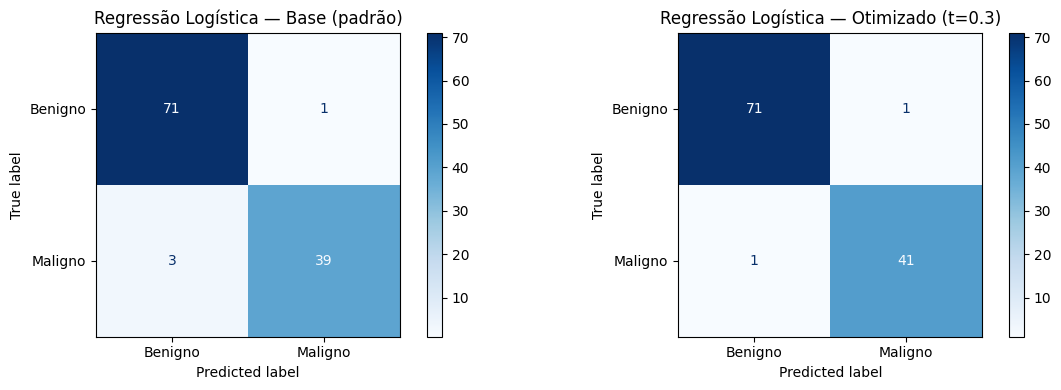

In [ ]:
# 7.2 Matrizes de confusão — base vs otimizado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, pred, title in zip(
    axes,
    [y_pred_baseline, y_pred_final],
    ["Base (padrão)", f"Otimizado (t={threshold_otimo})"]
):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Benigno", "Maligno"]).plot(ax=ax, cmap="Blues")
    ax.set_title(f"Regressão Logística — {title}")

plt.tight_layout()
plt.savefig("outputs/matriz_lr_baseline_vs_otimizado.png", dpi=300, bbox_inches="tight")
plt.show()